In [17]:
import pandas as pd
import os

import seaborn as sns
import matplotlib.pyplot as plt

print(os.listdir('../data/week 4/'))

['.DS_Store', 'scales_description.csv', 'participants.csv', 'wearables.csv', 'blood_pressure.csv', 'surveys.csv', 'heart_rate.csv', 'weather.csv', 'hrv_measurements.csv', 'sleep.csv']


In [7]:
data_path = '../data/week 4/'

blood_pressure = pd.read_csv(data_path + 'blood_pressure.csv')
heart_rate = pd.read_csv(data_path + 'heart_rate.csv')
hrv = pd.read_csv(data_path + 'hrv_measurements.csv')
participants = pd.read_csv(data_path + 'participants.csv')
scales_desc = pd.read_csv(data_path + 'scales_description.csv')
sleep = pd.read_csv(data_path + 'sleep.csv')
surveys = pd.read_csv(data_path + 'surveys.csv')
wearables = pd.read_csv(data_path + 'wearables.csv')
weather = pd.read_csv(data_path + 'weather.csv')

blood_pressure.head(), heart_rate.head(), hrv.head()

(    user_code  measurement_datetime  diastolic  systolic  \
 0  01bad5a519  2020-04-29  22:33:33        100       150   
 1  01bad5a519  2020-04-30  01:33:33        100       150   
 2  01bad5a519  2020-04-30  09:16:38         95       140   
 3  01bad5a519  2020-04-30  12:16:38         95       140   
 4  01bad5a519  2020-05-01  06:58:06         80       130   
 
    functional_changes_index  circulatory_efficiency  kerdo_vegetation_index  \
 0                       NaN                     NaN                     NaN   
 1                       NaN                     NaN                     NaN   
 2                      3.38                  4545.0                     6.0   
 3                       NaN                     NaN                     NaN   
 4                      2.89                  4000.0                     NaN   
 
    robinson_index  
 0             NaN  
 1             NaN  
 2           141.4  
 3             NaN  
 4           104.0  ,
     user_code         

## Dataset Overview

The dataset by the Welltory team explores to detect patterns in patients who tested positive for COVID-19.

The research was performed in 2020 and gathers heart rate variability measurements, data from user-connected gadets, and patient provided physical and mental health assessments.

File loaded:
participants: Demographic and metadata about users
hrv_measurements.csv: Heart rate variability points
heart_rate.csv: Heart rate readings
blood_pressure.csv: Blood pressure readings
sleep.csv: Sleep duration + quality
surveys.csv: Self-reported symptoms
wearables.csv: Device data
weather.csv: Weather data
scales_description.csv: Descriptions of survey scales

Overall, this dataset provides a comprehenisve view of key user health metrics while being infected with COVID-19.

It should be possible to extrapolate interesting insights from them.

In [ ]:
# Check structure
for name, df in {
    "Participants": participants,
    "Surveys": surveys,
}.items():
    print(f"\n{name} — Shape: {df.shape}")
    print(df.info())



Participants — Shape: (185, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_code       185 non-null    object 
 1   gender          185 non-null    object 
 2   age_range       185 non-null    object 
 3   city            173 non-null    object 
 4   country         179 non-null    object 
 5   height          183 non-null    float64
 6   weight          185 non-null    float64
 7   symptoms_onset  147 non-null    object 
dtypes: float64(2), object(6)
memory usage: 11.7+ KB
None

Surveys — Shape: (2259, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2259 entries, 0 to 2258
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_code   2259 non-null   object
 1   scale       2259 non-null   object
 2   created_at  2259 non-null   object
 3   value       2259 

In [9]:
# Extrapolate time frame from heart_rate.csv
heart_rate['datetime'] = pd.to_datetime(heart_rate['datetime'])
first_time = heart_rate['datetime'].min()
last_time = heart_rate['datetime'].max()
print(f"First recorded heart rate: {first_time}")
print(f"Last recorded heart rate: {last_time}")

First recorded heart rate: 2020-01-01 00:00:00
Last recorded heart rate: 2020-06-19 08:40:13


## Data Sampling

Source: Voluntary users of Welltory app
Sampling Size: 185 users
Sampling Method: Non-random self selected
Estimated Timeframe: 2020-01-01 00:00:00 -> 2020-06-19 08:40:13

Limitations:
Not representative of general population
Potential bias due to wearable device accuracy
Missing data

In [11]:
hrv.info()
hrv.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3245 entries, 0 to 3244
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_code             3245 non-null   object 
 1   rr_code               3245 non-null   object 
 2   measurement_datetime  3245 non-null   object 
 3   time_of_day           3245 non-null   object 
 4   bpm                   3245 non-null   int64  
 5   meanrr                3245 non-null   float64
 6   mxdmn                 3245 non-null   float64
 7   sdnn                  3245 non-null   float64
 8   rmssd                 3245 non-null   float64
 9   pnn50                 3245 non-null   float64
 10  mode                  3245 non-null   float64
 11  amo                   3245 non-null   float64
 12  lf                    3245 non-null   float64
 13  hf                    3245 non-null   float64
 14  vlf                   3245 non-null   float64
 15  lfhf                 

,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,...,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,...,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8..."
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,...,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83..."
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,...,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73..."
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,...,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75..."
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,...,489.0,128.0,96.0,3.820,713.0,0,0,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76..."


## HRV Structure

This data file represents patient data regarding specific heart rate variablity (hrv) measurements such as sdnn (reflects overall HRV and autonomic nervous system imbalance), rmssd (indicates short term HRV and rest-digest activity), and bpm (heart beats per minute)

Data is linked to user code and time series.

In [14]:
hrv[['rmssd', 'sdnn', 'bpm']].describe()

,rmssd,sdnn,bpm
count,3245.000000,3245.000000,3245.000000
mean,52.814196,52.489218,73.257935
std,39.353213,29.369506,12.201088
min,6.340000,9.515000,44.000000
25%,28.985000,32.585000,65.000000
50%,42.869000,46.919000,72.000000
75%,62.485000,64.406000,81.000000
max,310.800000,206.631000,125.000000


## Descriptive Statistics

The standard deviation for rmssd is much more significant than sdnn and bpm, indicating a wider variability in rest and recovery. 

rmssd and sdnn are slightly right skewed.

The difference between lowest and highest rmssd, sdnn, and bpm are staggering.

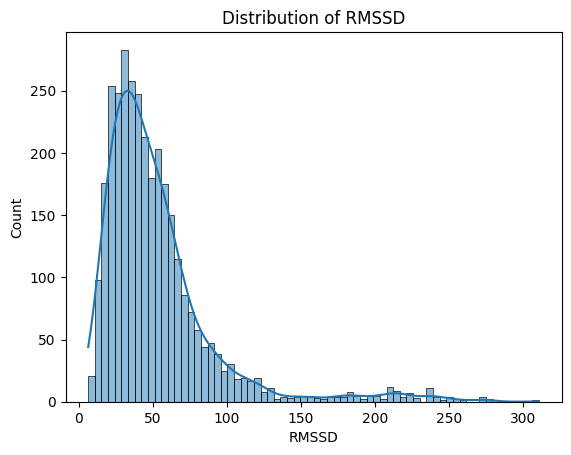

In [18]:
# RMSSD distribution
sns.histplot(hrv['rmssd'], kde=True)
plt.title('Distribution of RMSSD')
plt.xlabel('RMSSD')
plt.show()